In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
from google.colab import drive
from tqdm import tqdm
import dlib
#!pip install mediapipe
#import mediapipe as mp
import seaborn as sns
from scipy.fftpack import fft2, fftshift
from scipy import ndimage
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm
from PIL import Image
from time import time
from sklearn.datasets import fetch_olivetti_faces
from sklearn.decomposition import PCA
from skimage.feature import hog
from imutils import face_utils
import argparse
import imutils
import cv2
!wget http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
!bunzip2 shape_predictor_68_face_landmarks.dat.bz2

!pip install insightface onnxruntime
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPClassifier


from insightface.app import FaceAnalysis
import warnings
warnings.filterwarnings('ignore')

drive.mount('/content/drive')

--2025-12-08 03:03:02--  http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Resolving dlib.net (dlib.net)... 107.180.26.78
Connecting to dlib.net (dlib.net)|107.180.26.78|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2 [following]
--2025-12-08 03:03:02--  https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Connecting to dlib.net (dlib.net)|107.180.26.78|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 64040097 (61M)
Saving to: ‘shape_predictor_68_face_landmarks.dat.bz2’

shape_predictor_68_ 100%[===================>]  61.07M  38.8MB/s    in 1.6s    

2025-12-08 03:03:04 (38.8 MB/s) - ‘shape_predictor_68_face_landmarks.dat.bz2’ saved [64040097/64040097]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 439.5/439.5 kB 7.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing

TODO

- test on on the validation set
- Add model type for each param tried
- Add Timer wrapper

In [ ]:
path = "drive/MyDrive/datasci281/"
X_train = np.load(path + "X_train_embeddings.npy")
y_train = np.load(path + "y_train_embeddings.npy")


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

print("Scaled shape:", X_scaled.shape)

Scaled shape: (28709, 1548)


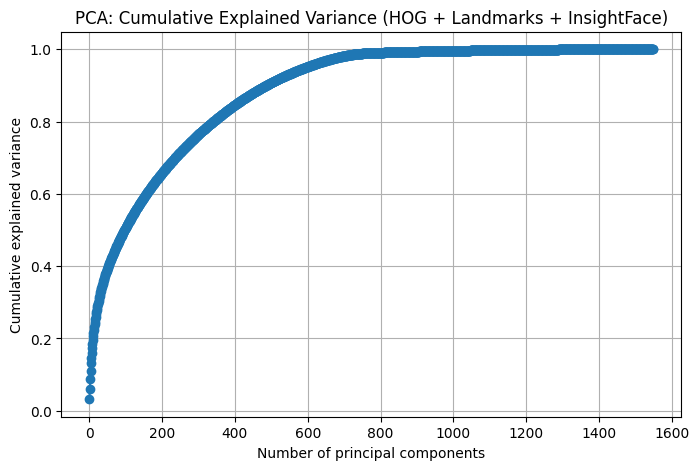

90% variance → 486 components
95% variance → 596 components
99% variance → 785 components


In [ ]:
# Fit PCA on all components to inspect variance
pca_full = PCA(svd_solver="randomized", random_state=42)
pca_full.fit(X_scaled)

expl_var = pca_full.explained_variance_ratio_
cum_var = np.cumsum(expl_var)

plt.figure(figsize=(8,5))
plt.plot(np.arange(1, len(cum_var)+1), cum_var, marker='o')
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.grid(True)
plt.title("PCA: Cumulative Explained Variance (HOG + Landmarks + InsightFace)")
plt.show()

# Optional: print how many components to reach 90%, 95%
for target in [0.90, 0.95, 0.99]:
    k = np.searchsorted(cum_var, target) + 1
    print(f"{target*100:.0f}% variance → {k} components")

In [ ]:
pca = PCA(n_components=596, svd_solver="randomized", random_state=42)
X_pca = pca.fit_transform(X_train)

print("Original shape:", X_train.shape)
print("Reduced shape:", X_pca.shape)  # e.g. (28709, ~200)

Original shape: (28709, 1548)
Reduced shape: (28709, 596)


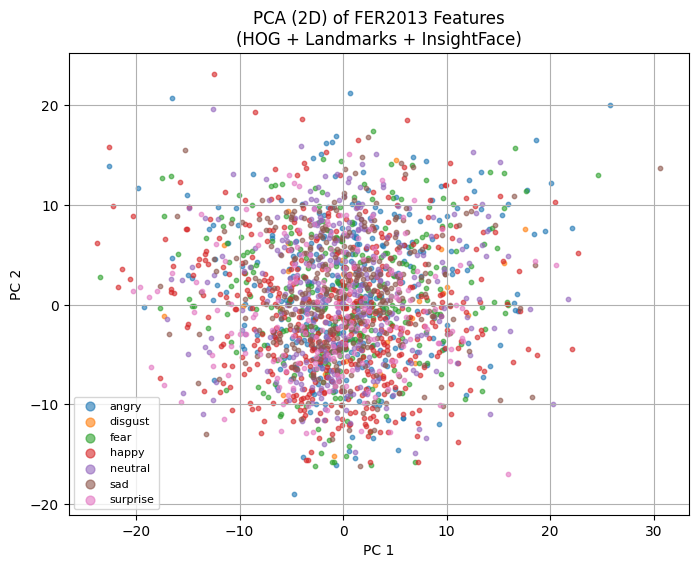

In [ ]:
emotion_names = ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']
# 2D PCA for visualization
pca_vis = PCA(n_components=2, svd_solver="randomized", random_state=42)
X_vis = pca_vis.fit_transform(X_scaled)

# Subsample for plotting
n_plot = 2000
idx = np.random.choice(X_vis.shape[0], size=n_plot, replace=False)
X_vis_sub = X_vis[idx]
y_sub = y_train[idx]  # make sure y aligns with X_final

# If y are numeric 0–6, use emotion_names; if already strings, you can skip mapping
try:
    y_labels = np.array([emotion_names[int(c)] for c in y_sub])
except:
    y_labels = y_sub  # assume already strings

plt.figure(figsize=(8, 6))
for emo in np.unique(y_labels):
    mask = (y_labels == emo)
    plt.scatter(X_vis_sub[mask, 0],
                X_vis_sub[mask, 1],
                s=10,
                alpha=0.6,
                label=emo)

plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.title("PCA (2D) of FER2013 Features\n(HOG + Landmarks + InsightFace)")
plt.legend(markerscale=2, fontsize=8)
plt.grid(True)
plt.show()

### Split the code Train and Validation Set

In [ ]:
X_train, X_Val, y_train, y_Val = train_test_split(
    X_pca,
    y_train,
    test_size=0.30,      # 30% goes to val
    random_state=42,
    stratify=y_train
)
print("Train shape:", X_train.shape)
print("Val shape:", X_Val.shape)

Train shape: (20096, 596)
Temp (val+test) shape: (8613, 596)


In [ ]:
def check_distribution(name, labels):
    unique, counts = np.unique(labels, return_counts=True)
    print(f"\n{name} distribution:")
    for u, c in zip(unique, counts):
        print(f"{emotion_names[int(u)]:>10}: {c}")

check_distribution("Train", y_train)
check_distribution("Validation", y_Val)



Train distribution:
     angry: 2797
   disgust: 305
      fear: 2868
     happy: 5050
       sad: 3381
  surprise: 2220
   neutral: 3475

Validation distribution:
     angry: 1198
   disgust: 131
      fear: 1229
     happy: 2165
       sad: 1449
  surprise: 951
   neutral: 1490


In [ ]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(
    max_iter=2000,
    n_jobs=-1,
    multi_class="multinomial",
    class_weight="balanced"
)
param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],   # regularization strength
    "solver": ["lbfgs", "saga"],         # compatible with multinomial
    "penalty": ["l2"]                    # safe + stable
}

In [ ]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    estimator=clf,
    param_grid=param_grid,
    scoring="f1_macro",     # best metric for FER2013
    cv=5,
    verbose=2,
    n_jobs=-1
)

In [ ]:
grid_search.fit(X_train, y_train)


Fitting 5 folds for each of 12 candidates, totalling 60 fits


GridSearchCV(cv=5,
             estimator=LogisticRegression(class_weight='balanced',
                                          max_iter=2000,
                                          multi_class='multinomial',
                                          n_jobs=-1),
             n_jobs=-1,
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100], 'penalty': ['l2'],
                         'solver': ['lbfgs', 'saga']},
             scoring='f1_macro', verbose=2)

In [ ]:
print("Best Parameters:", grid_search.best_params_)


Best Parameters: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}


In [ ]:
best_clf = grid_search.best_estimator_

In [ ]:
best_clf.predict(X_Val)
best_clf.predict_proba(X_Val)

array([[1.31285794e-01, 2.80315800e-07, 2.56305254e-01, ...,
        5.99921325e-01, 1.38506534e-04, 1.20949853e-02],
       [7.71915408e-02, 4.13015054e-03, 9.92482619e-02, ...,
        5.72427349e-01, 2.69279442e-04, 1.75094964e-01],
       [1.47893767e-01, 4.42487840e-11, 1.50606382e-02, ...,
        7.00351146e-02, 4.04484459e-02, 6.61139645e-01],
       ...,
       [1.73551138e-01, 2.82632775e-10, 6.42465112e-02, ...,
        1.02459054e-02, 4.92430504e-01, 1.19437442e-01],
       [2.77042609e-02, 3.60248448e-04, 7.11248294e-02, ...,
        5.95878399e-03, 7.72222984e-01, 3.15034468e-02],
       [1.63969461e-03, 1.34348788e-07, 3.15908503e-02, ...,
        2.74995272e-04, 9.23240579e-01, 4.28274530e-02]])

In [40]:
from sklearn.metrics import accuracy_score

val_preds = best_clf.predict(X_Val)
val_acc = accuracy_score(y_Val, val_preds)

print("Validation Accuracy:", val_acc)

Validation Accuracy: 0.5807500290258911


In [41]:
print(X_Val.shape)
print(y_Val.shape)
print(type(best_clf))

(8613, 596)
(8613,)
<class 'sklearn.linear_model._logistic.LogisticRegression'>


In [43]:
cm = confusion_matrix(y_Val, val_preds)
print(cm)

[[ 611   64  142   89  119   59  114]
 [  20   82   16    3    6    4    0]
 [ 176   41  431   89  221  142  129]
 [ 105   27   96 1664   81   78  114]
 [ 142   60  199   69  665   67  247]
 [  45   20   91   46   16  692   41]
 [  95   42  122  105  193   76  857]]


<Figure size 640x480 with 0 Axes>

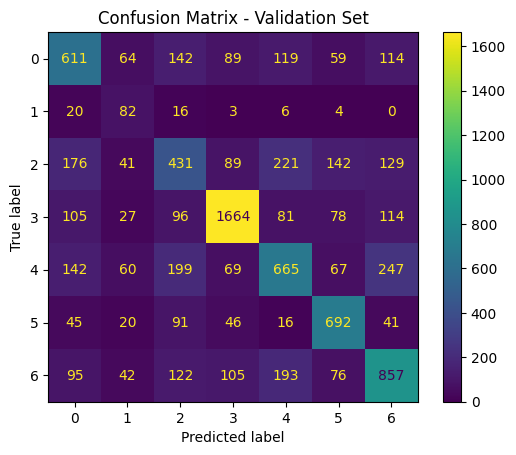

In [45]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

plt.figure()
disp.plot()
plt.title("Confusion Matrix - Validation Set")
plt.show()